n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      120 |      5 |             - |             -
     2 |      240 |      3 |  0.3835881886 |         ideal
     3 |      360 |      5 |  0.0650355117 |         ideal
     4 |      480 |      5 |  0.4581580440 |         ideal
     5 |      600 |      5 |  0.0297985207 |             f
     6 |      720 |      4 |  0.0875666703 |             f
     7 |      840 |      3 |  0.3088631166 |         nadir
     8 |      960 |      4 |  0.0351796645 |         nadir
     9 |     1080 |      3 |  0.8615733380 |         nadir
    10 |     1200 |      6 |  0.0998771023 |         ideal
    11 |     1320 |      7 |  0.0132805079 |             f
    12 |     1440 |      5 |  0.2488303140 |         nadir
    13 |     1560 |      6 |  2.6068845047 |         nadir
    14 |     1680 |      5 |  0.7420913342 |         ideal
    15 |     1800 |      4 |  0.2036743036 |         ideal
    16 |     1920 |      4 |  0.0405252057 |         nad

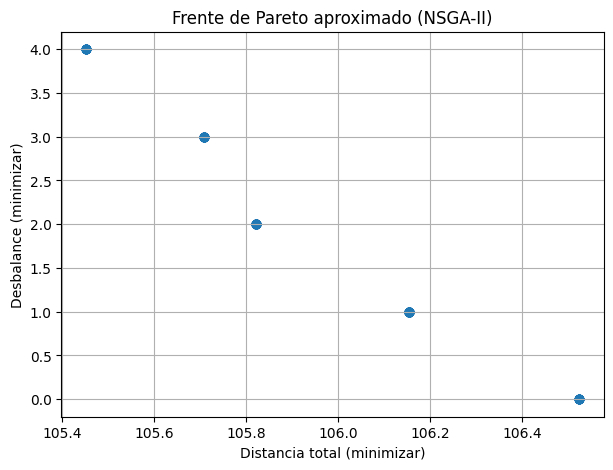

----- Solución seleccionada (heurística) -----
K (vehículos): 2
Objetivos [distancia_total, desbalance]: [105.82124216   2.        ]


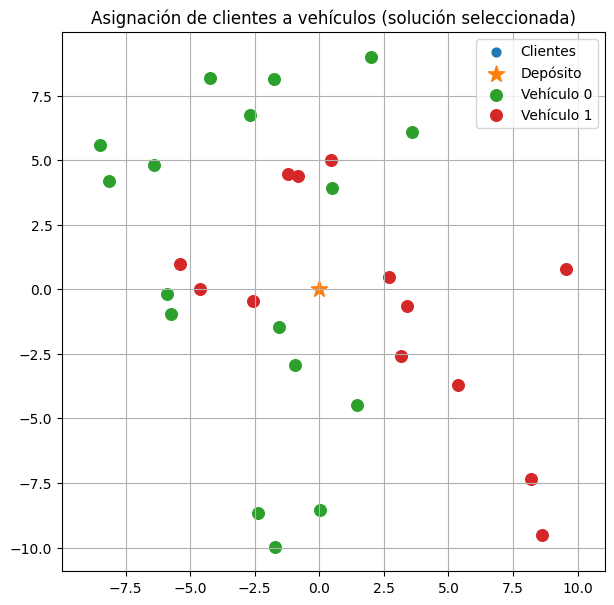

In [4]:
# ============================================================
# NSGA-II para un problema logístico multiobjetivo (didáctico)
# Google Colab-ready (CORREGIDO)
#
# Problema:
# - Depósito + N clientes en 2D (sintéticos)
# - Decidir K (#vehículos) y asignación cliente->vehículo
# - Objetivos:
#   (1) Minimizar distancia total recorrida
#   (2) Minimizar desbalance de carga entre vehículos
#
# NOTA DIDÁCTICA:
# - No resuelve el VRP/TSP exacto: estima distancia con "nearest neighbor".
# - El cromosoma decide K y asignación cliente->vehículo.
# ============================================================

!pip -q install pymoo

import numpy as np
import matplotlib.pyplot as plt

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.optimize import minimize
from pymoo.termination import get_termination


# --------------------------
# 1) Datos sintéticos
# --------------------------
np.random.seed(7)

N_CLIENTS = 30
K_MIN, K_MAX = 2, 6

depot = np.array([0.0, 0.0])  # Depósito en (0,0)
clients = np.random.uniform(low=-10, high=10, size=(N_CLIENTS, 2))

# Demandas sintéticas (opcional, por si quieres balancear demanda)
demands = np.random.randint(1, 10, size=N_CLIENTS)


def nearest_neighbor_route_length(depot_xy, points_xy):
    """
    Estima distancia de ruta con heurística de vecino más cercano:
    depósito -> visita clientes (orden greedy) -> depósito.
    """
    if len(points_xy) == 0:
        return 0.0

    unvisited = points_xy.copy()
    current = depot_xy.copy()
    dist = 0.0

    while len(unvisited) > 0:
        dists = np.linalg.norm(unvisited - current, axis=1)
        idx = np.argmin(dists)
        dist += dists[idx]
        current = unvisited[idx]
        unvisited = np.delete(unvisited, idx, axis=0)

    dist += np.linalg.norm(current - depot_xy)  # volver al depósito
    return float(dist)


# --------------------------
# 2) Problema para NSGA-II (CORREGIDO con ElementwiseProblem)
# --------------------------
class LogisticsNSGA2Problem(ElementwiseProblem):
    def __init__(self, clients, depot, demands, kmin, kmax, balance_mode="count"):
        """
        balance_mode:
          - "count": balancea #clientes por vehículo (simple y didáctico)
          - "demand": balancea suma de demandas por vehículo
        """
        self.clients = clients
        self.depot = depot
        self.demands = demands
        self.kmin = int(kmin)
        self.kmax = int(kmax)
        self.balance_mode = balance_mode

        n_var = 1 + clients.shape[0]  # K + asignación de N clientes

        # Límites de decisión (IMPORTANTE: arrays numéricos, compatibles con pymoo)
        xl = np.zeros(n_var, dtype=int)
        xu = np.zeros(n_var, dtype=int)

        xl[0] = self.kmin
        xu[0] = self.kmax

        xl[1:] = 0
        xu[1:] = self.kmax - 1

        super().__init__(
            n_var=n_var,
            n_obj=2,
            n_constr=0,
            xl=xl,
            xu=xu
        )

    def _evaluate(self, x, out, *args, **kwargs):
        """
        x llega como vector 1D (un individuo) gracias a ElementwiseProblem.
        """
        # Decodificar K
        K = int(np.round(x[0]))
        K = int(np.clip(K, self.kmin, self.kmax))

        # Asignaciones crudas en [0..Kmax-1], pero para el K real usamos mod K
        assign_raw = x[1:].astype(int)
        assign = assign_raw % K

        # Agrupar clientes por vehículo
        vehicle_clients = [[] for _ in range(K)]
        vehicle_demands = [[] for _ in range(K)]

        for i, v in enumerate(assign):
            vehicle_clients[v].append(self.clients[i])
            vehicle_demands[v].append(self.demands[i])

        # Objetivo 1: distancia total estimada
        total_dist = 0.0
        for v in range(K):
            pts = np.array(vehicle_clients[v])
            total_dist += nearest_neighbor_route_length(self.depot, pts)

        # Objetivo 2: desbalance
        if self.balance_mode == "count":
            loads = np.array([len(vehicle_clients[v]) for v in range(K)], dtype=float)
        else:  # "demand"
            loads = np.array([np.sum(vehicle_demands[v]) for v in range(K)], dtype=float)

        imbalance = float(np.std(loads))

        out["F"] = np.array([total_dist, imbalance], dtype=float)


problem = LogisticsNSGA2Problem(
    clients=clients,
    depot=depot,
    demands=demands,
    kmin=K_MIN,
    kmax=K_MAX,
    balance_mode="count"   # cambia a "demand" si quieres balancear demanda
)


# --------------------------
# 3) Configurar NSGA-II
# --------------------------
algorithm = NSGA2(
    pop_size=120,
    sampling=IntegerRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

termination = get_termination("n_gen", 150)


# --------------------------
# 4) Ejecutar optimización
# --------------------------
res = minimize(
    problem,
    algorithm,
    termination,
    seed=7,
    verbose=True
)


# --------------------------
# 5) Frente de Pareto
# --------------------------
F = res.F
X = res.X

plt.figure(figsize=(7, 5))
plt.scatter(F[:, 0], F[:, 1])
plt.xlabel("Distancia total (minimizar)")
plt.ylabel("Desbalance (minimizar)")
plt.title("Frente de Pareto aproximado (NSGA-II)")
plt.grid(True)
plt.show()


# --------------------------
# 6) Elegir una solución y visualizar asignación
# --------------------------
def decode_solution(x, n_clients, kmin, kmax):
    K = int(np.round(x[0]))
    K = int(np.clip(K, kmin, kmax))
    assign = (x[1:1+n_clients].astype(int) % K)
    return K, assign


# Selección heurística: normaliza objetivos y minimiza suma
F_norm = (F - F.min(axis=0)) / (F.max(axis=0) - F.min(axis=0) + 1e-12)
best_idx = np.argmin(F_norm.sum(axis=1))

best_x = X[best_idx]
best_f = F[best_idx]
best_K, best_assign = decode_solution(best_x, N_CLIENTS, K_MIN, K_MAX)

print("----- Solución seleccionada (heurística) -----")
print(f"K (vehículos): {best_K}")
print(f"Objetivos [distancia_total, desbalance]: {best_f}")

plt.figure(figsize=(7, 7))
plt.scatter(clients[:, 0], clients[:, 1], s=40, label="Clientes")
plt.scatter(depot[0], depot[1], s=150, marker="*", label="Depósito")

for v in range(best_K):
    idxs = np.where(best_assign == v)[0]
    if len(idxs) > 0:
        plt.scatter(clients[idxs, 0], clients[idxs, 1], s=70, label=f"Vehículo {v}")

plt.title("Asignación de clientes a vehículos (solución seleccionada)")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()